In [1]:
# https://www.kaggle.com/code/ricardomoya/an-lisis-de-sentimientos-clasificaci-n-de-textos
# https://www.kaggle.com/datasets/ricardomoya/criticas-peliculas-filmaffinity-en-espaniol
# http://sedici.unlp.edu.ar/bitstream/handle/10915/20745/Documento_completo.pdf?sequence=1#:~:text=La%20temprana%20clasificaci%C3%B3n%20de%20idiomas%20y%20detecci%C3%B3n%20de,se%20encuentran%2C%20por%20tener%20errores%20de%20alg%C3%BAn%20tipo.

!python -m spacy download es_core_news_sm
#!python -m pip install pactools

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import re
from tqdm import tqdm
#from pactools.grid_search import GridSearchCVProgressBar
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score
import itertools
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#from google.colab import files

# Importamos el modelo en español de spacy
nlp =spacy.load('es_core_news_sm')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 13.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
df = pd.read_csv('https://github.com/palasatenea66/DATASETS/raw/main/reviews_filmaffinity.csv', sep="\|\|", header=0, engine='python')
df.sample(5)

,film_name,gender,film_avg_rate,review_rate,review_title,review_text
1366,El orfanato,Terror,"6,7",6.0,Un poquito de cada,"Eso es lo que tiene ""El Orfanato"", un poquito ..."
4492,Días de fútbol,Comedia,"6,1",7.0,Éxito fuera de las fronteras espanolas,"Esta película es, para muchos aficionados al c..."
4968,Mientras dure la guerra,Drama,"6,8",8.0,Una sopresa. Viva el cine Español.,"Tras una carrera algo desinflada de Amenabar, ..."
3624,Alatriste,Aventuras,"5,5",1.0,Bazofia a millonaria,No me permito perder tiempo en criticar esta s...
4393,Superlópez,Comedia,"4,4",8.0,El gran héroe español,"""SuperLópez"" mucho antes de convertirse en un ..."


In [3]:
df.shape

(8603, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8603 entries, 0 to 8602
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   film_name      8603 non-null   object 
 1   gender         8603 non-null   object 
 2   film_avg_rate  8603 non-null   object 
 3   review_rate    8601 non-null   float64
 4   review_title   8603 non-null   object 
 5   review_text    8603 non-null   object 
dtypes: float64(1), object(5)
memory usage: 403.4+ KB


In [5]:
df.describe()

,review_rate
count,8601.000000
mean,5.870596
std,2.550581
min,1.000000
25%,4.000000
50%,6.000000
75%,8.000000
max,10.000000


In [ ]:
df['gender'].unique()

array(['Comedia', 'Drama', 'Terror', 'Aventuras', 'Animación', 'Thriller',
       'Musical', 'Romance', 'Fantástico', 'Intriga', 'Cine negro'],
      dtype=object)

In [ ]:
df.groupby('gender').film_name.nunique()

,film_name
gender,
Animación,4
Aventuras,2
Cine negro,1
Comedia,20
Drama,10
Fantástico,1
Intriga,1
Musical,1
Romance,2


In [ ]:
df.groupby('gender').film_name.nunique().sum()

np.int64(46)

In [3]:
# 1.- Nueva columna con la polaridad de los votos:
# DEFINIMOS MÁS DE 6 COMO POSITIVO, ENTRE 4 Y 6 COMO NEUTRO Y MENOS DE 4 COMO NEGATIVO
df['polaridad'] = df['review_rate'].apply(lambda  x: 'positivo' if x > 6
                                          else ('negativo' if x < 4
                                                else 'neutro'))
print(df.shape)
df.sample(10)

(8603, 7)


,film_name,gender,film_avg_rate,review_rate,review_title,review_text,polaridad
4429,El otro lado de la cama,Musical,"6,4",10.0,Feliz comedia con actores en estado de gracia,Parecía impensable que a este director le pudi...,positivo
7215,Los crímenes de Oxford,Intriga,"5,7",8.0,"Veo a Elijah y veo a Frodo, no lo puedo remediar",La película tiene un comienzo un poco lento pe...,positivo
364,Ocho apellidos vascos,Comedia,"6,0",5.0,"Aquí es ji ji, allí es ja ja",Como no podía ser de otro modo finalmente acab...,neutro
3622,Alatriste,Aventuras,"5,5",3.0,ALATRISTE ME DEJA TRISTE,Tras leer las críticas vertidas sobre el film ...,negativo
7579,REC,Terror,"6,6",4.0,Una más de terror.,Después de escuchar tantas críticas buenas ten...,neutro
6057,Es por tu bien,Comedia,"5,1",6.0,PRÍNCIPES DESTRONADOS,Tres de los primeros espadas de la escena espa...,neutro
3686,Alatriste,Aventuras,"5,5",2.0,De pena,"De pena, vamos. Esperaba mucho, lo dio de verd...",negativo
4959,Mientras dure la guerra,Drama,"6,8",4.0,Un poco sobrevalorada.,Normalmente suelo coincidir con las puntuacion...,neutro
7830,AirBag,Comedia,"6,6",1.0,"Esta película sólo es comparable a Torrente 4,...","Pues eso, esta película sólo es comparable a T...",negativo
7250,Los crímenes de Oxford,Intriga,"5,7",7.0,Enigmas de Oxford,Una película interesante. Se retoma como en mu...,positivo


In [ ]:
print(df['film_name'].unique())         # nombres de las pelis
print(len(df['film_name'].unique()))    # cantidad de películas distintas

['Ocho apellidos vascos' 'Lo imposible' 'Ocho apellidos catalanes'
 'El orfanato' 'La gran aventura de Mortadelo y Filemón'
 'Torrente 2: Misión en Marbella' 'Ágora' 'Perfectos desconocidos'
 'Mar adentro' 'Torrente 4' 'Campeones' 'Las aventuras de Tadeo Jones'
 'Torrente 3' 'Tadeo Jones 2' 'Palmeras en la nieve' 'Alatriste'
 'Celda 211' 'Superlópez' 'El otro lado de la cama' 'Días de fútbol'
 'Tengo ganas de ti' 'Planet 51' 'Lo dejo cuando quiera'
 'Atrapa la bandera' 'Torrente, el brazo tonto de la ley'
 'Mientras dure la guerra' 'Torrente 5' 'Perdiendo el norte' 'Volver'
 'Villaviciosa de al lado' 'Todo sobre mi madre'
 'Tres metros sobre el cielo' 'Es por tu bien' 'La niña de tus ojos'
 'Regresión' 'El laberinto del fauno' 'Juana La Loca' 'Ahora o nunca'
 'Los crímenes de Oxford' 'REC' 'AirBag' 'Las 13 rosas' 'El bola'
 'El mejor verano de mi vida' 'Los dos lados de la cama' 'La isla mínima']
46


Text(30.764506172839504, 0.5, 'Nº Votos')

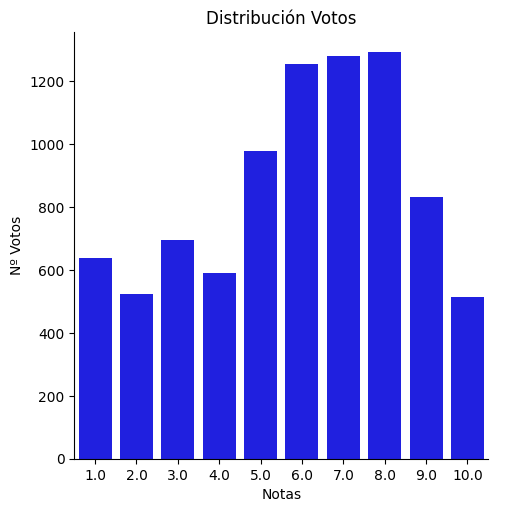

In [18]:
# UN POCO DE CONOCER EL DATASET...
# 2.-  Distribución numérica de los votos de las críticas.

sns.catplot(x='review_rate', kind='count', color='b', data=df)
plt.title('Distribución Votos')
plt.xlabel('Notas')
plt.ylabel('Nº Votos')

Text(-3.6805555555555554, 0.5, 'Nº Votos')

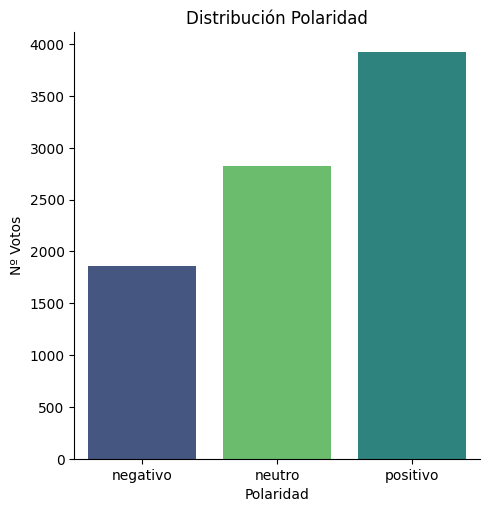

In [19]:
# 3.-  Distribución de votos por polaridad

sns.catplot(x='polaridad', kind='count', data=df,  order=['negativo', 'neutro', 'positivo'], hue='polaridad', legend=False, palette='viridis')
plt.title('Distribución Polaridad')
plt.xlabel('Polaridad')
plt.ylabel('Nº Votos')

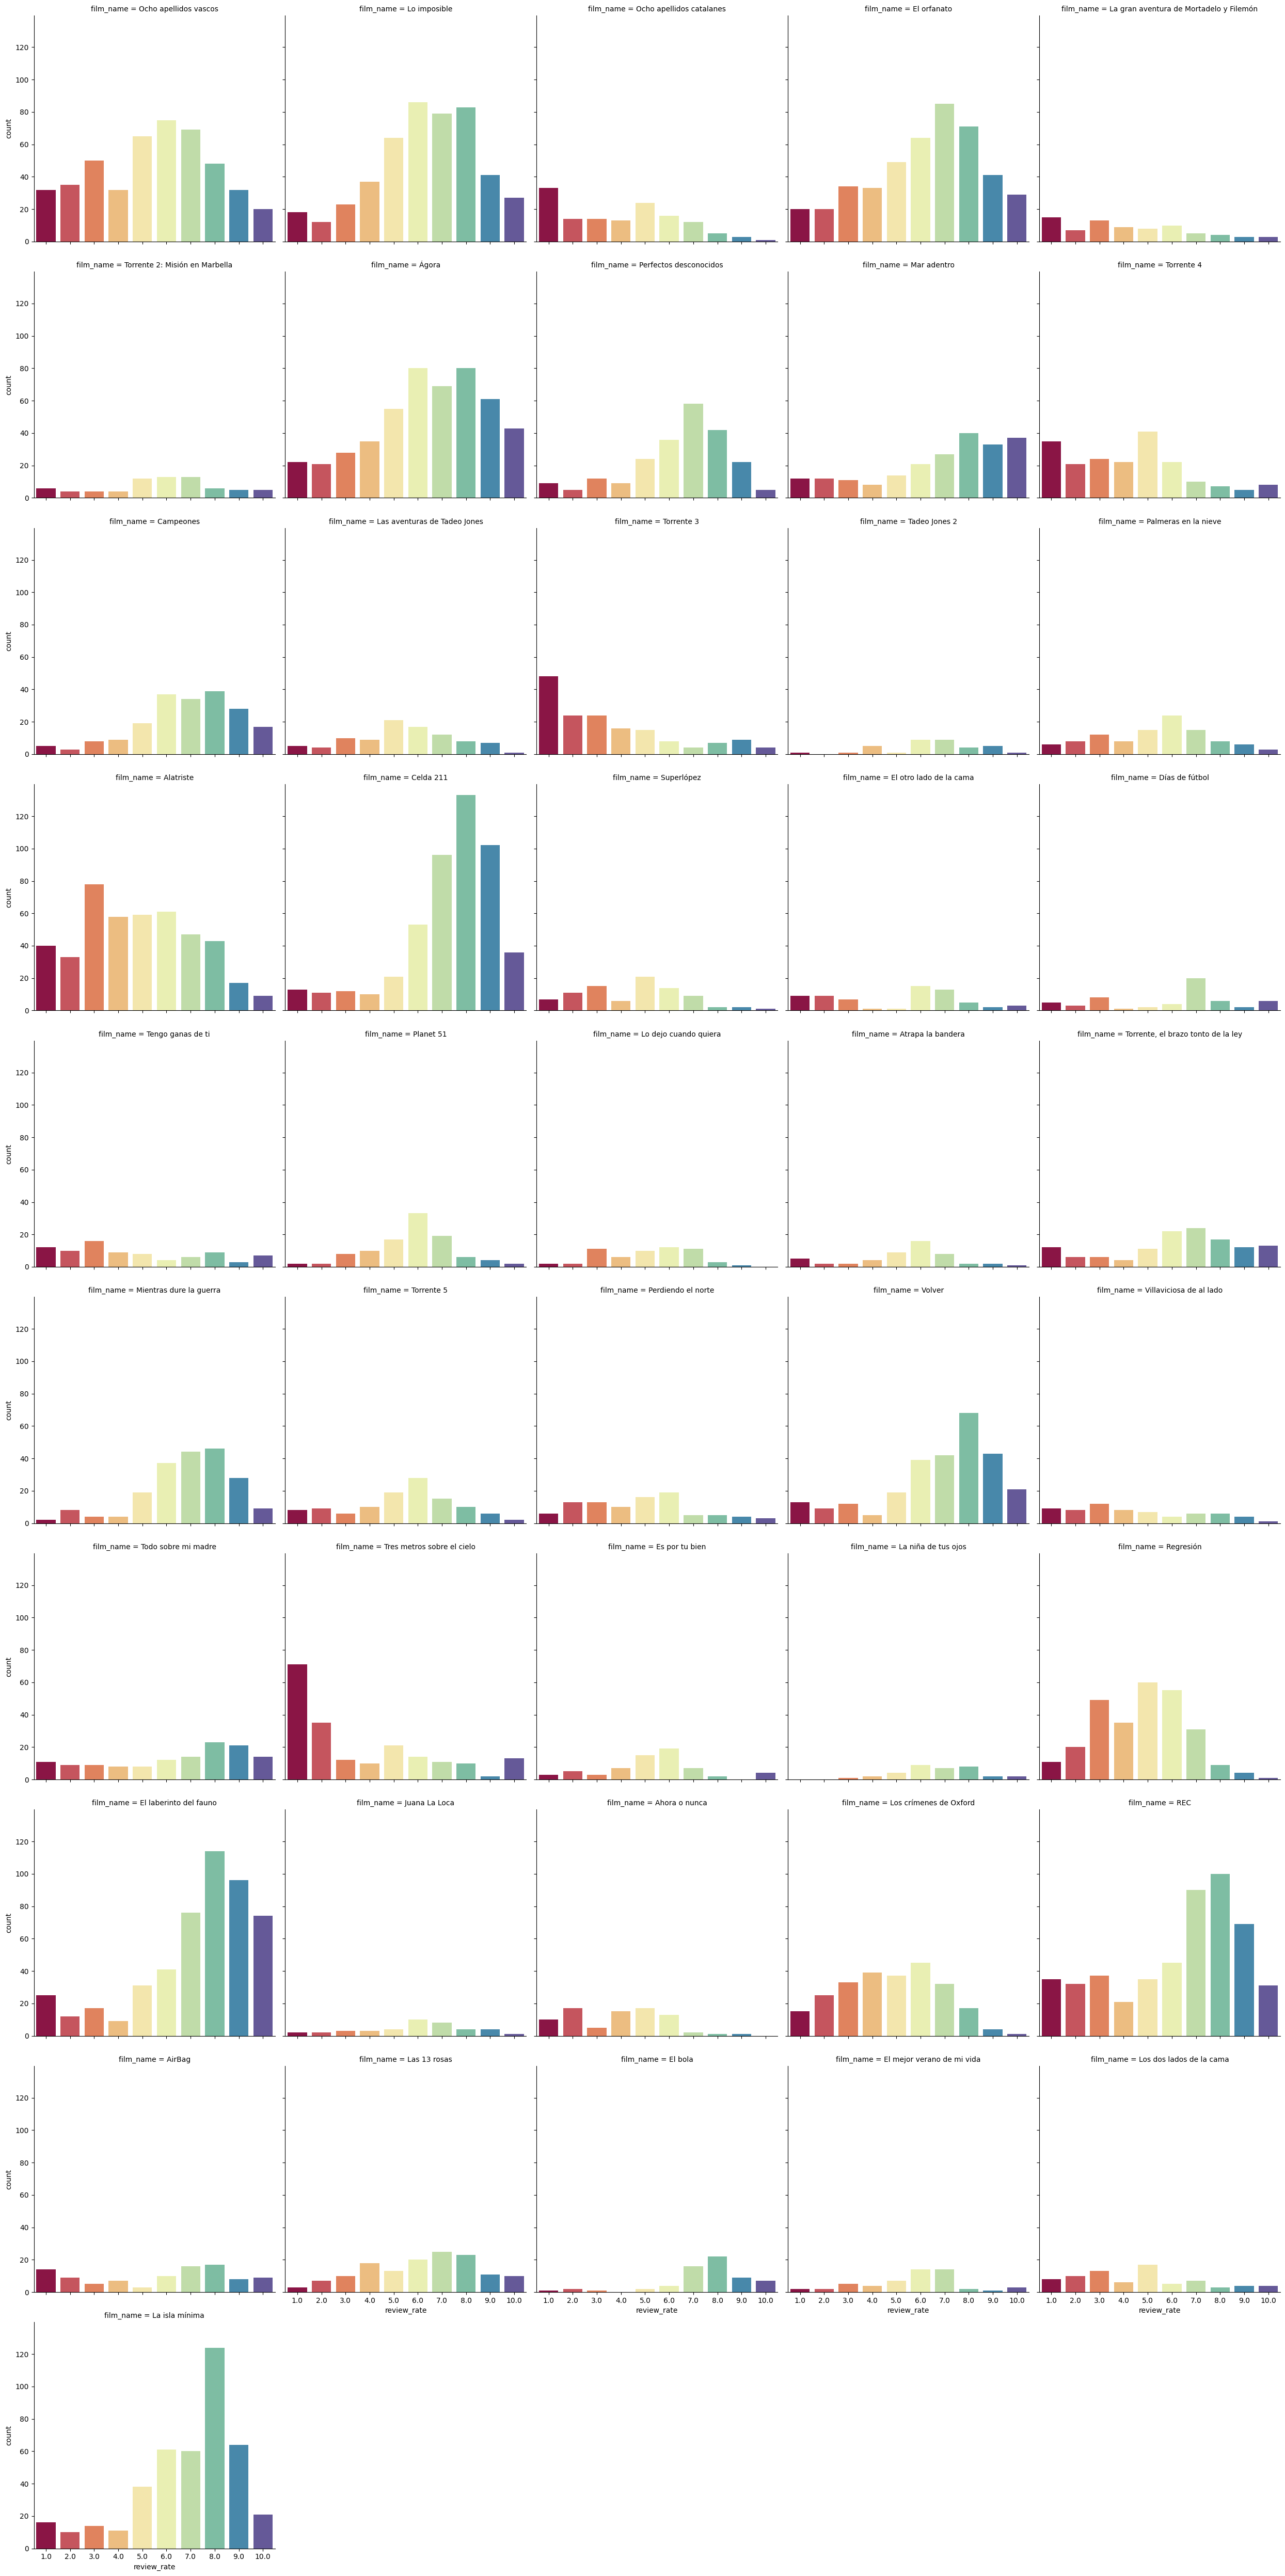

In [20]:
# 4.- Distribución de los votos por película.

sns.catplot(x="review_rate", col="film_name", data=df, kind='count', col_wrap=5, hue='review_rate', legend=False, palette='Spectral')

# 3.- Normalización de textos
Vamos a definir como texto a clasificar el Título y la Crítica, ya que el título aporta significado al texto.

En este punto realizaremos los siguientes pasos:

*Concatenación de título y crítica

*Pasamos a array de numpy el texto y el target (polaridad)

*Importamos el modelo de spacy en español

Normalización de los textos:

La normalización es una tarea que tiene como objetivo poner todo el texto en igualdad de condiciones; como por ejemplo:

*Pasar todo el texto a minúsculas (o mayúsculas)

*Eliminar signos de puntuación (puntos, comas, comillas, etc)

*Quitar las stopwords: palabras que no aportan significado a los textos

*Convertir números a su equivalente a palabras

*Transformar la palabra a su lema

*Pasar emoticonos a textos

etc.

In [4]:
# 1.- Concatenación de título y crítica

df['texto'] = df['review_title'] + ' ' + df['review_text']
df.head(5)

,film_name,gender,film_avg_rate,review_rate,review_title,review_text,polaridad,texto
0,Ocho apellidos vascos,Comedia,"6,0",3.0,OCHO APELLIDOS VASCOS...Y NINGÚN NOMBRE PROPIO,La mayor virtud de esta película es su existen...,negativo,OCHO APELLIDOS VASCOS...Y NINGÚN NOMBRE PROPIO...
1,Ocho apellidos vascos,Comedia,"6,0",2.0,El perro verde,"No soy un experto cinéfilo, pero pocas veces m...",negativo,"El perro verde No soy un experto cinéfilo, per..."
2,Ocho apellidos vascos,Comedia,"6,0",2.0,Si no eres de comer mierda... no te comas esta...,Si no eres un incondicional del humor estilo T...,negativo,Si no eres de comer mierda... no te comas esta...
3,Ocho apellidos vascos,Comedia,"6,0",2.0,Aida: The movie,"No sé qué está pasando, si la gente se deja ll...",negativo,"Aida: The movie No sé qué está pasando, si la ..."
4,Ocho apellidos vascos,Comedia,"6,0",2.0,UN HOMBRE SOLO (Julio Iglesias 1987),"""Pero cuando amanece,y me quedo solo,siento en...",negativo,"UN HOMBRE SOLO (Julio Iglesias 1987) ""Pero cua..."


In [5]:
# 2.- Pasamos a array de numpy el texto (X) y el target-polaridad (y)

X = df['texto'].values
y = df['polaridad'].values

In [14]:
y

array(['negativo', 'negativo', 'negativo', ..., 'neutro', 'negativo',
       'negativo'], dtype=object)

In [10]:
# 3.- Definimos la normalización

def normalize(corpus):
    """Función que dada una lista de textos, devuelve esa misma lista de textos
       con los textos normalizados, realizando las siguientes tareas:
       1.- Pasamos la palabra a minúsculas
       2.- Elimina signos de puntuación
       3.- Elimina las palabras con menos de 3 caracteres (palabras que seguramente no aporten significado)
       4.- Elimina las palabras con más de 11 caracteres (palabras "raras" que seguramente no aporten significado)
       5.- Elimina las stopwords (palabras que no aportan significado como preposiciones, determinantes, etc.)
       6.- Elimina los saltos de línea (en caso de haberlos)
       7.- Eliminamos todas las palabras que no sean Nombres, adjetivos, verbos o adverbios
    """
    for index, doc in enumerate(tqdm(corpus)):
        doc = nlp(doc.lower())
        corpus[index] = " ".join([word.lemma_ for word in doc if (not word.is_punct)
                                  and (len(word.text) > 3)
                                  and (len(word.text) < 11)
                                  and (not word.is_stop)
                                  and re.sub(r'[^a-zA-Z\s*]', ' ', word.text)
                                  and (word.pos_ in ['NOUN', 'ADJ', 'VERB', 'ADV'])])


    return corpus

# Normalización
X_norm = normalize(X)       # tarda unos 6 minutos


100%|██████████| 8603/8603 [01:36<00:00, 88.82it/s]


####Explicación de los parámetros dados a re.sub()
#### s -> espacios en blanco
#### [ ] -> se coloca la expresión regular adentro
#### ^ -> excluye lo que sigue
#### a-z -> de 'a' a 'z' minúsculas y mayúsculas
#### * -> todas las repeticiones desde 0 (es decir, aunque aparezca una sola vez)
#### \\ -> cierra la selección

[Fuente](https://es.stackoverflow.com/questions/324366/eliminar-signos-y-simbolos-de-una-cadena-en-python)

In [11]:
np.unique(X_norm)

array(['-dicser orfanato miedo miedo miedo llamar cagado cine repetitivo resultar aburrido previsible cosa esquivado accidente huir dañino tópico americano sello profundo original nivel ciencio ficción terror americano francés italiano polaco nigerián objetivo plenamente creer fusión subgénero unido aplicado medido causar pavor dejar exhausto espectador sala encender elección conocido televisión vecino aumentar veracidad relatar creer arrancar oreja bocado duración acertado cortar facilidad introducir medida cámara persona durar caer aburrir minuto marcar tiempo tensión exagerado instante derrotar espectador dejar sensación pagar cuarto fila director gustar película dormir entrar vivir dirigir guiño raro suceso acaecido edificio urbano español frágil evidente cinta orfanato orfanato aspecto técnico historio convencido miedo',
       '0261 bautizar crear máquina controlado destruido elección elección elegir cuestión existencia causar horror causar yo.nunca compensar daño causé servir gr

In [12]:
X_norm.shape

(8603,)

In [15]:
# 4.- Bolsa de Palabras (BoW) - Particionado de datos
# Particionamos los textos en entrenamiento y test (80% entrenamiento, 20% test)

X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=0, stratify=y)

print(f'Textos de entrenamiento: {len(X_train)}')
print(f'Textos de test: {len(X_test)}')

Textos de entrenamiento: 6882
Textos de test: 1721


[]

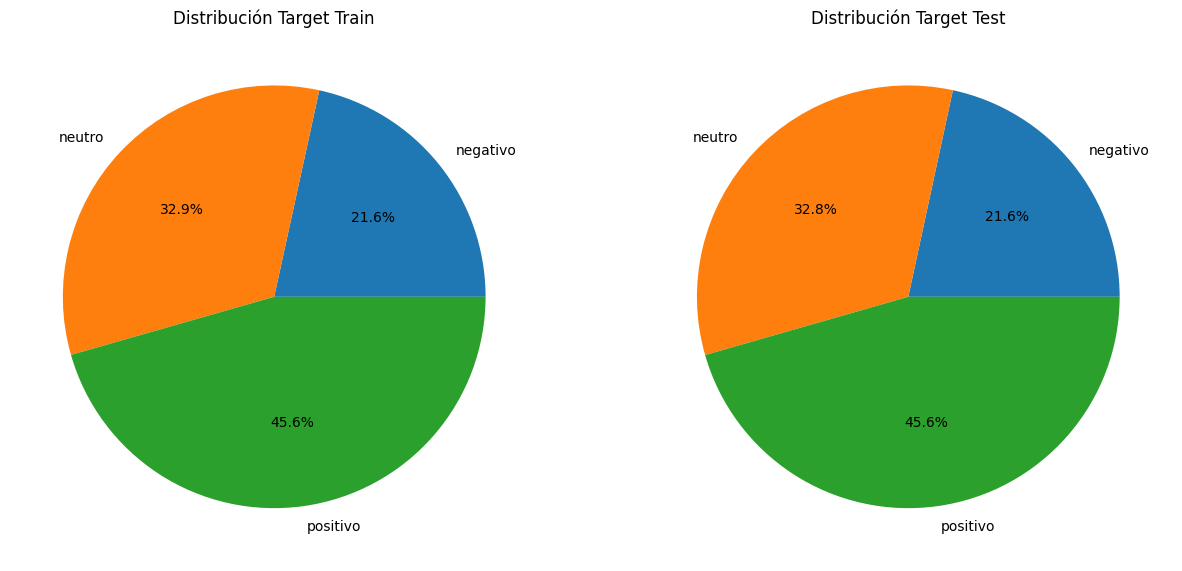

In [16]:
keys_train, counts_train = np.unique(y_train, return_counts=True)
keys_test, counts_test = np.unique(y_test, return_counts=True)
percent_train = counts_train / np.sum(counts_train)
percent_test = counts_test / np.sum(counts_test)

plt.figure(figsize=(15, 15))
plt.subplot(1, 2, 1)
plt.pie(percent_train, labels=keys_train, autopct='%1.1f%%')
plt.title('Distribución Target Train')
plt.subplot(1, 2, 2)
plt.pie(percent_test, labels=keys_test, autopct='%1.1f%%')
plt.title('Distribución Target Test')
plt.plot()

In [17]:
# https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html
bow = CountVectorizer(max_features=2000, min_df=3, strip_accents='ascii')

# Creamos el modelo de bolsa de palabras con los textos de entrenamiento y aplicamos el modelo
X_bow_train = bow.fit_transform(X_train)

# A modo de ejemplo mostramos las 20 primeras palabras de la bolsa de palabras
bow.get_feature_names_out()[0:21]

array(['abajo', 'abandonar', 'abarcar', 'abierto', 'abordar', 'abrir',
       'absoluto', 'absurdo', 'abundar', 'aburrido', 'aburrir', 'abusar',
       'abuso', 'acabado', 'acabar', 'acaso', 'accidente', 'accion',
       'acento', 'aceptable', 'aceptar'], dtype=object)

In [19]:
bow.get_feature_names_out()[:].size

2000

In [20]:
X_bow_test = bow.transform(X_test)

In [21]:
type(X_bow_test)

scipy.sparse._csr.csr_matrix

In [22]:
# Ahora vamos a buscar los parámetros para entrenar una máquina de soporte vectorial
# PRIMERO USAREMOS UNA BÚSQUEDA RANDOMIZADA Y LUEGO UNA BÚSQUEDA POR CUADRÍCULA
# PRIMERO RANDOMIZED SEARCH Y LUEGO usaremos GridSearch, AMBOS vienen con un cross validation incluido :)
'''
class sklearn.model_selection.RandomizedSearchCV(estimator, param_distributions, *, n_iter=10, scoring=None, n_jobs=None,
refit=True, cv=None, verbose=0, pre_dispatch='2*n_jobs', random_state=None, error_score=nan, return_train_score=False)
class sklearn.model_selection.GridSearchCV(estimator, param_grid, *, scoring=None,
n_jobs=None, refit=True, cv=None, verbose=0, pre_dispatch='2*n_jobs', error_score=nan,
return_train_score=False)
'''
param_range = [0.01, 0.1, 1.0, 10.0]
param_grid = [{'C': param_range,'kernel': ['linear']}, {'C': param_range,'gamma': param_range,'kernel': ['rbf']}]
svc = SVC(random_state=1)  # para que sea reproducible el resultado
# # 10 folds y todos los procesadores y que use el score de la svm

rs = RandomizedSearchCV(estimator=SVC(random_state=1), param_distributions=param_grid, n_iter=10, scoring=None, cv=5, n_jobs=-1, verbose=1)  # 5 folds y todos los procesadores
rs.fit(X_bow_train, y_train)
print(f'Mejor score: {100*rs.best_score_} %')
print(f'Mejores parámetros: {rs.best_params_}')


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejor score: 63.61552329803584 %
Mejores parámetros: {'kernel': 'rbf', 'gamma': 0.01, 'C': 1.0}


In [23]:
# https://stackoverflow.com/questions/24121018/sklearn-gridsearch-how-to-print-out-progress-during-the-execution
# A CONTINUACIÓN HAREMOS UNA BÚSQUEDA DE CUADRÍCULA CON GRID SEARCH USANDO COMO PUNTO
# DE PARTIDA LOS RESULTADOS DE LA BÚSQUEDA RAMDOMIZADA, algo así como hacer zoom en esa zona
'''
# RECORDAR QUE LE HEMOS CONFIGURADO CV=5, ES DECIR HIZO CROSS VALIDATION CON 5 CORRIDAS
ÚLTIMA CORRIDA
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejor score: 63.61552329803584 %
Mejores parámetros: {'kernel': 'rbf', 'gamma': 0.01, 'C': 1.0}
'''
param_range_gamma = [0.005, 0.01, 0.015]  #[0.004, 0.006, 0.008, 0.01, 0.012, 0.014, 0.016]
param_range_C = [0.5, 1.0, 5.0]
param_grid = [{'C': param_range_C,'gamma': param_range_gamma, 'kernel': ['rbf']}, {'C': param_range_C, 'kernel': ['linear']}]

#

gs = GridSearchCV(estimator=SVC(random_state=1), param_grid=param_grid, scoring=None, cv=5, n_jobs=-1, verbose=1)  # 10 folds y todos los procesadores
gs.fit(X_bow_train, y_train)
print(f'Mejor score: {100*gs.best_score_} %')
print(f'Mejores parámetros: {gs.best_params_}')


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Mejor score: 63.61552329803584 %
Mejores parámetros: {'C': 1.0, 'gamma': 0.01, 'kernel': 'rbf'}


In [25]:
# UNA SEGUNDA MIRADITA...
'''
ÚLTIMA CORRIDA
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Mejor score: 63.61552329803584 %
Mejores parámetros: {'C': 1.0, 'gamma': 0.01, 'kernel': 'rbf'}
'''
param_range_gamma2 = [0.006, 0.008, 0.01, 0.012, 0.014]
param_range_C2 = [0.7, 1.0, 2.0]
param_grid = [{'C': param_range_C2, 'gamma': param_range_gamma2,'kernel': ['rbf']}]

gs = GridSearchCV(estimator=SVC(random_state=1), param_grid=param_grid, scoring=None, cv=5, n_jobs=-1, verbose=1)  # 10 folds y todos los procesadores
gs.fit(X_bow_train, y_train)
print(f'Mejor score: {100*gs.best_score_} %')
print(f'Mejores parámetros: {gs.best_params_}')

'''
RESULTADO
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Mejor score: 64.29845172349732 %
Mejores parámetros: {'C': 2.0, 'gamma': 0.006, 'kernel': 'rbf'}
'''


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Mejor score: 64.29845172349732 %
Mejores parámetros: {'C': 2.0, 'gamma': 0.006, 'kernel': 'rbf'}


"\nRESULTADO\nFitting 10 folds for each of 3 candidates, totalling 30 fits\nMejor score: 65.09763053971041 %\nMejores parámetros: {'C': 0.02, 'kernel': 'linear'}\n"

tn, fp, fn, tp = [160 123  89  65 321 179  27 107 650]
Val_accuracy_svm= 65.71760604299826 %


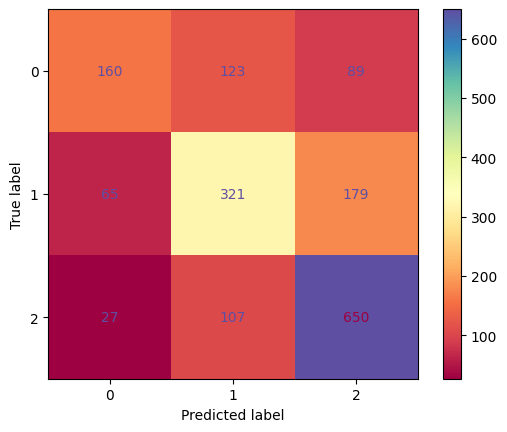

In [26]:
# Veamos la matriz de confusión
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html

svm=gs.best_estimator_        # elegimos el que mejor salió
svm.fit(X_bow_train, y_train)     # entrenamos...
y_pred_sv=svm.predict(X_bow_test)  # ... y predecimos sobre el cjto de validación
# matriz de confusión
print(f'tn, fp, fn, tp = {confusion_matrix(y_test, y_pred_sv).ravel()}')
# más 'bonita'
conf_svm = confusion_matrix(y_test, y_pred_sv)
ConfusionMatrixDisplay(conf_svm).plot(cmap='Spectral')
print(f'Val_accuracy_svm= {100*svm.score(X_bow_test, y_test)} %')

# TODOS LOS BLOQUES A CONTINUACIÓN SON DEL NOTEBOOK ORIGINAL, DONDE NO SE HIZO UNA BÚSQUEDA DE PARÁMETROS, SINO QUE SE USARON LOS QUE VIENEN ESTABLECIDOS POR DEFAULT EN SVC

In [27]:
# TODOS LOS BLOQUES A CONTINUACIÓN SON DEL NOTEBOOK ORIGINAL, DONDE NO SE HIZO UNA
# BÚSQUEDA DE PARÁMETROS, SINO QUE SE USÓ LOS QUE VIENEN ESTABLECIDOS POR DEFAULT




svm_lin = SVC(kernel='linear')
svm_rbf = SVC(kernel='rbf')

clasificadores = {'SVM lineal': svm_lin,
                  'SVM Kernel rbf': svm_rbf}


# Ajustamos los modelos y calculamos el accuracy para los datos de entrenamiento
for k, v in clasificadores.items():
    print ('CREANDO MODELO: {clas}'.format(clas=k))
    v.fit(X_bow_train, y_train)

CREANDO MODELO: SVM lineal
CREANDO MODELO: SVM Kernel rbf


In [28]:
def evaluation(model, name, X_train, y_train, X_test, y_test):
    """
    Función de devuelve en un diccionario las métricas de evaluación de
    Accuracy, Precision, Recall y F1 para los conjuntos de datos de entrenamiento y test
        model: modelo a evaluar
        name: nombre del modelo
        X_train: Variables de entrada del conjunto de datos de entrenamiento
        y_train: Variable de salida del conjunto de datos de entrenamiento
        X_test: Variables de entrada del conjunto de datos de test
        y_test: Variable de salida del conjunto de datos de test
        return: diccionario con el nombre del modelo y el valor de las métricas
    """
    model_dict = {}
    model_dict['name'] = name
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    model_dict['accuracy_train'] = accuracy_score(y_true=y_train, y_pred=y_pred_train)
    model_dict['accuracy_tests'] = accuracy_score(y_true=y_test, y_pred=y_pred_test)
    model_dict['precision_train'] = precision_score(y_true=y_train, y_pred=y_pred_train, average='weighted')
    model_dict['precision_tests'] = precision_score(y_true=y_test, y_pred=y_pred_test, average='weighted')
    model_dict['recall_train'] = recall_score(y_true=y_train, y_pred=y_pred_train, average='weighted')
    model_dict['recall_tests'] = recall_score(y_true=y_test, y_pred=y_pred_test, average='weighted')
    model_dict['f1_train'] = f1_score(y_true=y_train, y_pred=y_pred_train, average='weighted')
    model_dict['f1_tests'] = f1_score(y_true=y_test, y_pred=y_pred_test, average='weighted')

    return model_dict


# Calculamos las métricas de los modelos por separado
evaluacion = list()
for key, model in clasificadores.items():
    evaluacion.append(evaluation(model=model, name=key,
                                 X_train=X_bow_train, y_train=y_train,
                                 X_test=X_bow_test, y_test=y_test))

# Pasamos los resultados a un DataFrame para visualizarlos mejor
df = pd.DataFrame.from_dict(evaluacion)
df.set_index("name", inplace=True)
df


,accuracy_train,accuracy_tests,precision_train,precision_tests,recall_train,recall_tests,f1_train,f1_tests
name,,,,,,,,
SVM lineal,0.923714,0.582801,0.923508,0.588967,0.923714,0.582801,0.923389,0.58456
SVM Kernel rbf,0.879250,0.639163,0.881774,0.633942,0.879250,0.639163,0.877876,0.62358


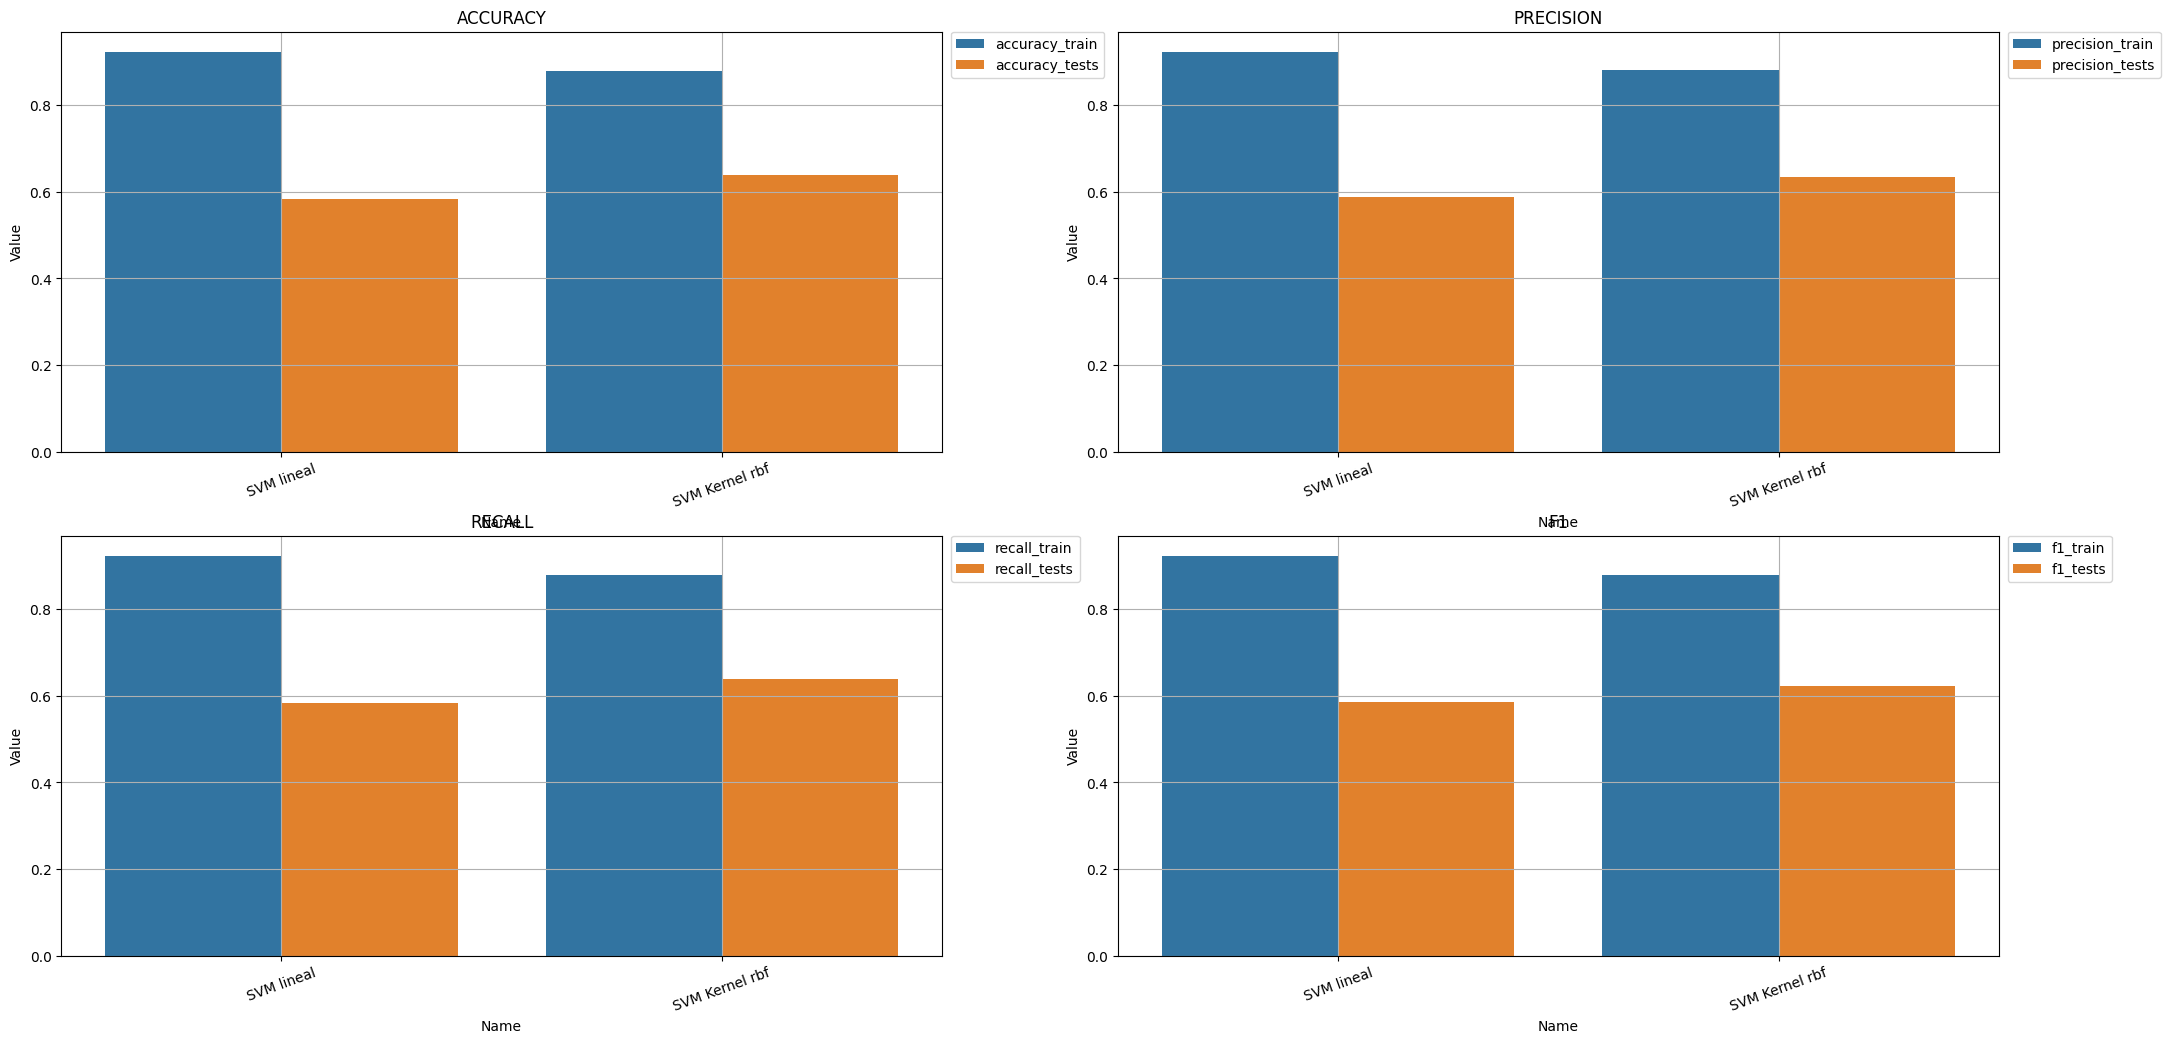

In [29]:
# Métricas a pintar
METRICS = ["accuracy", "precision", "recall", "f1"]

# Transformamos el dataframe para pintar las gráficas con seaborn
df_plot = df.reset_index().melt(id_vars='name').rename(columns=str.title)

plt.figure(figsize=(25, 12))
pos = 1
for metric in METRICS:
    # Filtramos la métrica a pintar
    df_aux = df_plot[df_plot['Variable'].str.contains(metric)]

    # Pintamos la gráfica en su posición 2x2
    plt.subplot(2, 2, pos)
    sns.barplot(x='Name', y='Value', hue='Variable', data=df_aux)
    plt.title(metric.upper())
    plt.grid()
    plt.legend(bbox_to_anchor=(1.01, 1), loc=2, borderaxespad=0.)
    plt.xticks(rotation=20)
    pos += 1
plt.show()


Obteniendo Matriz de Confusión de: SVM lineal
Obteniendo Matriz de Confusión de: SVM Kernel rbf


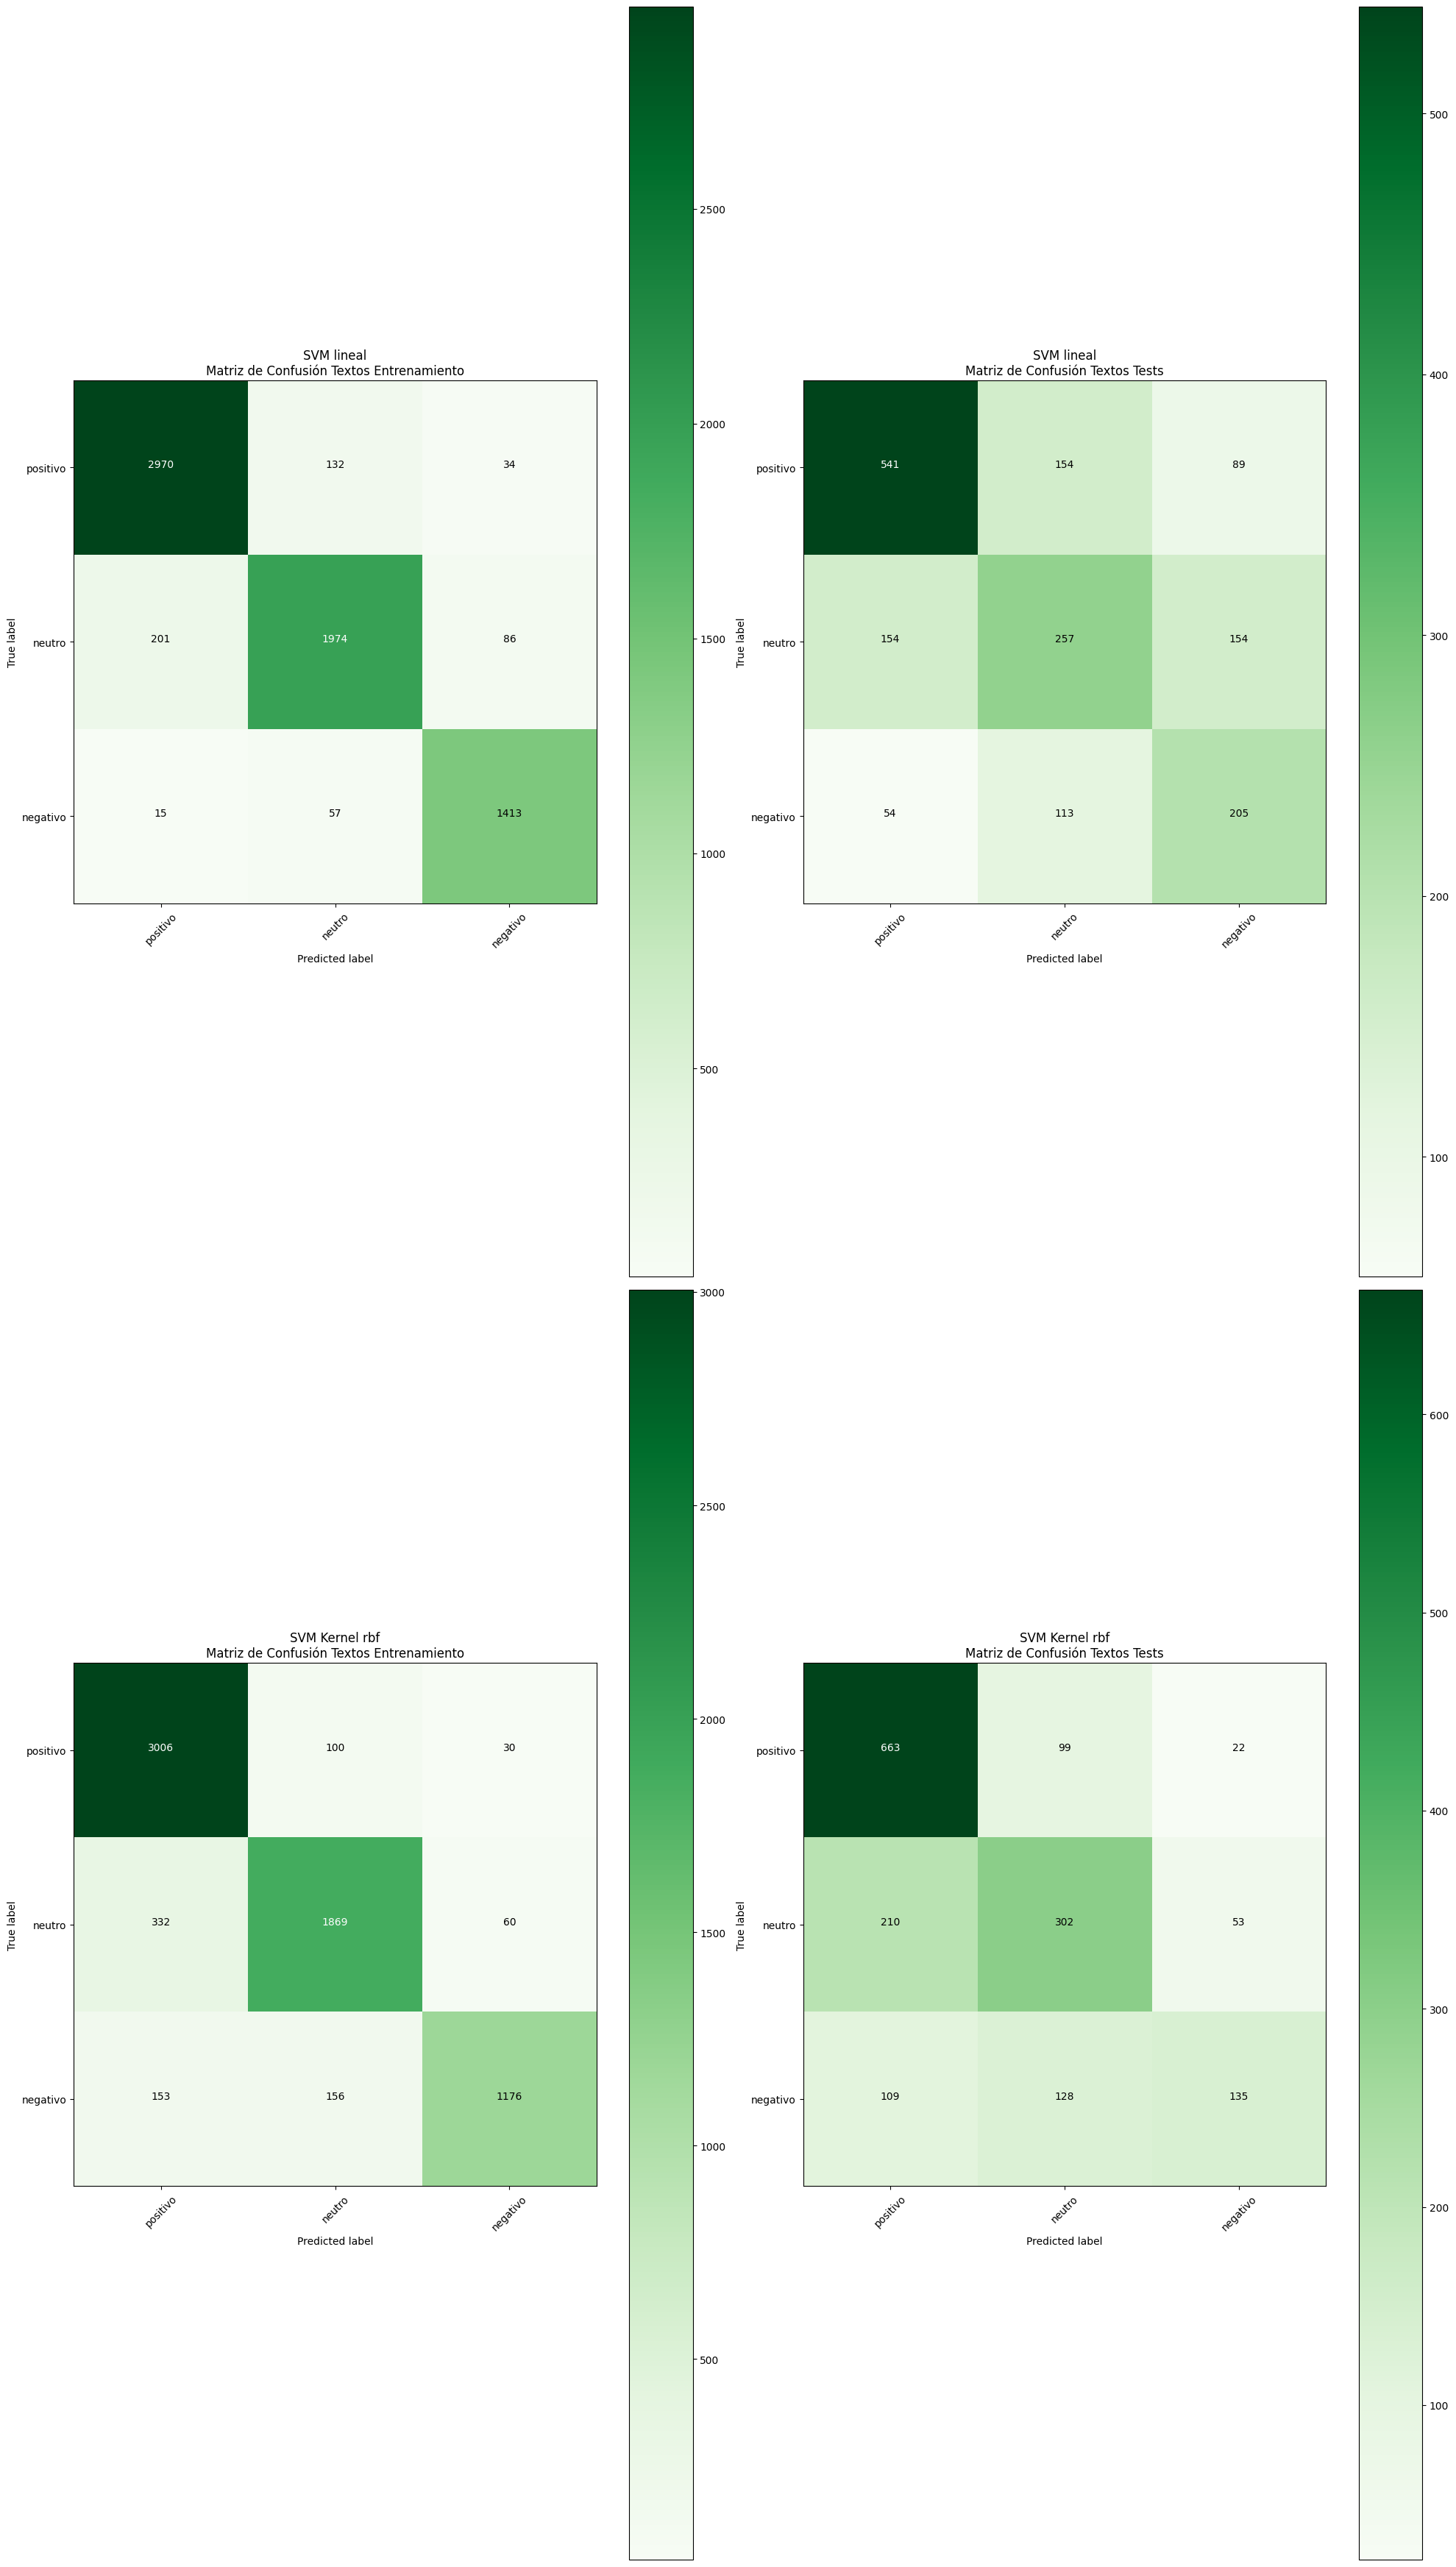

In [30]:
polaridad = ['positivo', 'neutro', 'negativo']

# Obtenemos las Matrices de confusión
msc = list()
for k, v in clasificadores.items():
    print ('Obteniendo Matriz de Confusión de: {model}'.format(model=k))
    model = {}
    model['name'] = k
    y_pred_train = v.predict(X_bow_train)
    y_pred_test = v.predict(X_bow_test)
    model['confusion_matrix_train'] = confusion_matrix(y_true=y_train, y_pred=y_pred_train, labels=polaridad)
    model['confusion_matrix_test'] = confusion_matrix(y_true=y_test, y_pred=y_pred_test, labels=polaridad)
    msc.append(model)


# Definimos el heatmap de la matriz de confusión
def plot_confusion_matrix(cm, classes, title, cmap=plt.cm.Greens):
    """
    This function prints and plots the confusion matrix.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'), horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')


# Pintamos las matrices de confusión
plt.figure(figsize=(20, 35))
pos = 0
for mc in msc:
    pos += 1
    plt.subplot(len(msc), 2, pos)
    plot_confusion_matrix(mc['confusion_matrix_train'], classes=polaridad,
                          title='{}\nMatriz de Confusión Textos Entrenamiento'.format(mc['name']))
    pos += 1
    plt.subplot(len(msc), 2, pos)
    plot_confusion_matrix(mc['confusion_matrix_test'], classes=polaridad,
                          title='{}\nMatriz de Confusión Textos Tests'.format(mc['name'] ))
plt.show()